# **Directed Influence Networks in Financial Systems: Granger Causality and Transfer Entropy, Part 1**

## Introduction

In complex financial systems, identifying who influences whom is not straightforward. When dealing with a large number of interacting entities—currencies, equities, institutions, or macro variables—the web of relationships quickly becomes too dense to interpret by inspection. Simple pairwise comparisons or visual inspection of time series often fail to reveal the underlying structure of influence, especially when relationships are indirect, lagged, or mediated through multiple channels.

This creates a fundamental challenge for quantitative analysts. While we may observe co-movements across assets, it is far more difficult to determine whether one variable systematically leads another, or whether both are driven by a common underlying factor. In large systems, influence is not only distributed but often directional and time-dependent, making naïve approaches insufficient for rigorous analysis.

To address this, we turn to network-based methods that explicitly model directional relationships. In particular, this notebook focuses on two complementary approaches: Granger causality and transfer entropy. Both methods aim to quantify whether past values of one time series contain information about the future values of another, thereby allowing us to construct directed networks of influence. Granger causality provides a model-based, typically linear framework, while transfer entropy offers a more general, information-theoretic perspective that can capture nonlinear dependencies.

The goal of this notebook is to demonstrate how these methods can be used to construct and analyze influence networks in a systematic way. We proceed in two stages. First, we perform a static analysis using the full time series to build an initial, intuitive understanding of the network structure. This serves as a clear and computationally simple baseline. Second, in Part 2, we extend the analysis to a rolling framework, allowing the network to evolve over time. This dynamic perspective is more aligned with real-world financial systems, where relationships are rarely stable and often shift across regimes.

By the end of this notebook, the reader should have a clear understanding of how to move from raw time series data to a structured representation of influence, and how to interpret that structure in a meaningful way.

## Granger Causality and Transfer Entropy

### **Linear Causality Considerations:**

Granger causality provides a model-based, **linear** notion of directed influence between time series. Let $\{X_t\}$ and $\{Y_t\}$ be covariance-stationary stochastic processes. Consider the following autoregressive representations of $Y_t$:

\begin{equation}
Y_t = \sum_{i=1}^{p} \alpha_i Y_{t-i} + \varepsilon_t^{(r)},
\end{equation}

\begin{equation}
Y_t = \sum_{i=1}^{p} \alpha_i Y_{t-i} + \sum_{j=1}^{p} \beta_j X_{t-j} + \varepsilon_t^{(u)},
\end{equation}

where $p$ is the chosen lag order, $\alpha_i$ and $\beta_j$ are coefficients, and $\varepsilon_t^{(r)}$, $\varepsilon_t^{(u)}$ are residuals from the restricted and unrestricted models, respectively.

**Definition.**
> We say that $X$ _Granger-causes_ $Y$ if the inclusion of lagged values of $X_t$ leads to a statistically significant reduction in the variance of the prediction error, i.e., if

> \begin{equation}
\mathrm{Var}(\varepsilon_t^{(u)}) < \mathrm{Var}(\varepsilon_t^{(r)}).
\end{equation}

In practice, this is tested using an F-test or likelihood ratio test. The resulting measure captures whether past values of $X$ improve the linear prediction of $Y$.

### **Nonliner Causality Considerations:**

Transfer entropy provides a **nonlinear**, information-theoretic measure of directed dependence. It quantifies the incremental information provided by the past of one process about the future of another, beyond what is already contained in its own past. Formally, the transfer entropy from $X$ to $Y$ is defined as:

\begin{equation}
T_{X \to Y} = \sum p(y_t, y_{t-1}^{(k)}, x_{t-1}^{(l)})
\ln \frac{p(y_t \mid y_{t-1}^{(k)}, x_{t-1}^{(l)})}{p(y_t \mid y_{t-1}^{(k)})},
\end{equation}

where $y_{t-1}^{(k)} = (Y_{t-1}, \dots, Y_{t-k})$ and $x_{t-1}^{(l)} = (X_{t-1}, \dots, X_{t-l})$ denote lagged vectors, and $p(\cdot)$ represents joint and conditional probability distributions.

A positive value of $T_{X \to Y}$ indicates that past values of $X$ reduce the uncertainty about $Y_t$, conditional on the past of $Y$, implying directed influence.

Both methods produce **directed, lag-dependent measures of influence**. Granger causality relies on linear parametric models and is computationally efficient, while transfer entropy is model-free and capable of capturing nonlinear dependencies, albeit at higher computational cost. In both cases, the pairwise influence measures can be assembled into a weighted adjacency matrix, which serves as the basis for network construction and subsequent analysis.

### Relation to Mutual Information

Transfer entropy is closely related to the concept of mutual information and can be understood as a conditional, time-directed extension of it.

Recall that mutual information measures the amount of shared information between two random variables. In the time series setting, however, we are interested not just in dependence, but in whether the past of one process helps predict the future of another. This leads naturally to a conditional formulation.

Since mutual information can be expressed as differences of entropies, transfer entropy ultimately inherits this structure. Formally, transfer entropy from $X$ to $Y$ can be written as:

\begin{equation}
T_{X \to Y} = \sum p(y_t, y_{t-1}^{(k)}, x_{t-1}^{(l)})
\ln \frac{p(y_t \mid y_{t-1}^{(k)}, x_{t-1}^{(l)})}{p(y_t \mid y_{t-1}^{(k)})} = I\big(X_{t-1}^{(l)} ; Y_t \mid Y_{t-1}^{(k)}\big),
\end{equation}

where $I(\cdot;\cdot \mid \cdot)$ denotes conditional mutual information, $x_{t-1}^{(l)} = (X_{t-1}, \dots, X_{t-l})$, and $y_{t-1}^{(k)} = (Y_{t-1}, \dots, Y_{t-k})$.

This expression states that transfer entropy measures how much uncertainty about $Y_t$ is reduced when incorporating the past of $X$, given that the past of $Y$ is already known. In other words, it isolates the **incremental predictive content** of $X$ for $Y$ that is not redundant with $Y$’s own history. A higher value of $T_{X \to Y}$ indicates that $X$ contributes meaningful additional information about the future evolution of $Y$, implying a stronger directed influence from $X$ to $Y$.

This representation makes the interpretation precise: transfer entropy measures how much additional information the past of $X$ provides about the present of $Y$, beyond what is already contained in the past of $Y$ itself.

Conceptually, the relationship can be summarized as a hierarchy:

\begin{equation}
\text{Entropy} \;\rightarrow\; \text{Mutual Information} \;\rightarrow\; \text{Conditional Mutual Information} \;\rightarrow\; \text{Transfer Entropy}.
\end{equation}

This perspective highlights that transfer entropy extends mutual information by introducing both conditioning and temporal direction, making it suitable for detecting directional influence in time series.

## Full-Sample Demonstration

We begin with a full-sample analysis to establish a clear and intuitive baseline for the methods introduced above. The objective of this section is to construct a directed influence network using the entire available time series, without yet introducing any time variation. This provides a simple, static view of the system that allows us to understand the mechanics of the approach before moving to a more realistic rolling framework. To maintain clarity and focus, the rolling, time-varying extension of this analysis will be developed in a separate notebook titled “*Directed Influence Networks in Financial Systems: Granger Causality and Transfer Entropy, Part 2*.”

The dataset used in this analysis, [`forex_cleaned.csv`](https://github.com/BenjaminZYT/Risk-Management/blob/main/data/forex_cleaned.csv), is obtained from *Bank Negara Malaysia* (the central bank of Malaysia) and represents the middle rates of foreign exchange against MYR, quoted at noon. As such, the data provides a consistent daily snapshot of currency valuations relative to the Malaysian Ringgit, making it suitable for studying cross-currency dynamics.

The analysis focuses on the following set of currencies:

| Symbol | Currency Name           |   | Symbol | Currency Name           |   | Symbol | Currency Name           |
|--------|------------------------|---|--------|------------------------|---|--------|------------------------|
| USD    | US Dollar              |   | HKD100 | Hong Kong Dollar (100) |   | VND100 | Vietnamese Dong (100)  |
| GBP    | British Pound Sterling |   | PHP100 | Philippine Peso (100)  |   | KHR100 | Cambodian Riel (100)   |
| EUR    | Euro                   |   | THB100 | Thai Baht (100)        |   | NZD    | New Zealand Dollar     |
| JPY100 | Japanese Yen (100)     |   | TWD100 | Taiwan Dollar (100)    |   | MMK100 | Myanmar Kyat (100)     |
| CHF    | Swiss Franc            |   | KRW100 | South Korean Won (100) |   | INR100 | Indian Rupee (100)     |
| AUD    | Australian Dollar      |   | IDR100 | Indonesian Rupiah (100)|   | AED100 | UAE Dirham (100)       |
| CAD    | Canadian Dollar        |   | SAR100 | Saudi Riyal (100)      |   | PKR100 | Pakistani Rupee (100)  |
| SGD    | Singapore Dollar       |   | CNY    | Chinese Yuan           |   | NPR100 | Nepalese Rupee (100)   |
| BND    | Brunei Dollar          |   | EGP    | Egyptian Pound         |   |        |                        |

The first step is to load the dataset and inspect its structure. Before proceeding with any transformations or modeling, it is important to understand the format and contents of the data. To this end, we display the first three and last three observations of the dataset using `head(3)` and `tail(3)`. This allows us to verify the time index, confirm the set of currencies included, and identify any immediate data issues such as missing values or irregular formatting.

Once the structure of the dataset is understood, we will proceed to compute log returns and construct pairwise directed influence measures using both transfer entropy and, subsequently, Granger causality. These pairwise measures will then be assembled into a network representation, forming the basis for the analysis that follows.

In [1]:
import pandas as pd

# Read the dataset
df_forex = pd.read_csv("forex_cleaned.csv")

# Inspect the first and last 3 rows
print("--- HEAD (3) ---")
display(df_forex.head(3))

print("\n--- TAIL (3) ---")
display(df_forex.tail(3))

--- HEAD (3) ---


,Date,USD,GBP,EUR,JPY100,CHF,AUD,CAD,SGD,HKD100,...,BND,VND100,KHR100,NZD,MMK100,INR100,AED100,PKR100,NPR100,EGP
0,2025-01-02,4.4775,5.6134,4.6438,2.8489,4.9489,2.7832,3.1145,3.2916,57.5988,...,3.2916,0.0176,0.1108,2.5148,0.2139,5.2230,121.9031,1.6084,3.2637,0.0881
1,2025-01-03,4.4950,5.5709,4.6166,2.8573,4.9285,2.7921,3.1248,3.2840,57.7827,...,3.2840,0.0177,0.1111,2.5190,0.2147,5.2403,122.3929,1.6139,3.2754,0.0885
2,2025-01-06,4.5130,5.6121,4.6558,2.8615,4.9626,2.8084,3.1332,3.2948,58.0439,...,3.2948,0.0178,0.1116,2.5372,0.2155,5.2606,122.8696,1.6205,3.2877,0.0890



--- TAIL (3) ---


,Date,USD,GBP,EUR,JPY100,CHF,AUD,CAD,SGD,HKD100,...,BND,VND100,KHR100,NZD,MMK100,INR100,AED100,PKR100,NPR100,EGP
302,2026-04-01,4.0350,5.3397,4.6649,2.5397,5.0551,2.7858,2.9006,3.1376,51.4787,...,3.1376,0.0153,0.1004,2.3131,0.1927,4.3069,109.8692,1.4456,2.6592,0.0740
303,2026-04-02,4.0315,5.3363,4.6526,2.5297,5.0514,2.7753,2.8984,3.1319,51.4376,...,3.1318,0.0153,0.1004,2.3036,0.1926,4.3212,109.7739,1.4339,2.6569,0.0753
304,2026-04-03,4.0340,5.3368,4.6538,2.5278,5.0507,2.7863,2.8969,3.1376,51.4662,...,3.1376,0.0153,0.1004,2.3032,0.1927,4.3492,109.8390,1.4456,2.6586,0.0744


### **Demonstration 1**: Transfer Entropy (TE) Network Construction (Full Sample)

We now construct a directed influence network using transfer entropy on the full sample of data. The objective of this step is to quantify pairwise, lagged information flow between currencies and assemble these relationships into a network representation.

For each ordered pair of currencies $(X, Y)$, we estimate the transfer entropy from $X$ to $Y$ using a fixed lag structure (`lag=1`). This yields a directed measure of influence, where higher values indicate stronger incremental predictive content from the source currency to the target currency. By repeating this procedure across all currency pairs, we obtain a full mesh of directed relationships.

The resulting output will be presented in two forms. First, we identify the strongest individual directed links in the system, highlighting the most prominent pairwise influences. Second, we aggregate the results to produce a ranking of currencies based on their average outgoing influence, providing a system-wide view of information leadership.

This analysis is based solely on transfer entropy. In the next section, we will perform an analogous construction using Granger causality, allowing for a direct comparison between the two approaches.

---

### **Note**

The next cell is a setup cell required for the transfer entropy computation. It installs and applies compatibility patches to the `PyCausality` library (available at https://github.com/ZacKeskin/PyCausality, developed by Zac Keskin), which is not fully aligned with newer Python, NumPy, and SciPy versions.

You may execute this cell directly without inspecting the code in detail. It does not affect the analysis logic, but ensures that the transfer entropy routines run correctly in the current environment.

In [2]:
# =========================================================
# Transfer Entropy setup for PyCausality
# =========================================================

# 1. Install required packages
!pip install PyCausality --no-deps
!pip install six

# 2. Standard imports
import numpy as np
import pandas as pd
import scipy
import sys

# 3. NumPy compatibility patch
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

# 4. scipy._lib.six compatibility patch
try:
    import six
except ImportError:
    !pip install six
    import six

if not hasattr(scipy, '_lib'):
    scipy._lib = type('obj', (object,), {})()

sys.modules['scipy._lib.six'] = six
print("Scipy dependency patch applied.")

# 5. Import PyCausality and the required internal modules
try:
    import PyCausality
    import PyCausality.Utils.Utils
    from PyCausality.TransferEntropy import TransferEntropy
    print("PyCausality loaded successfully.")
except ImportError:
    print("PyCausality not found. Re-installing...")
    !pip install PyCausality --no-deps
    import PyCausality
    import PyCausality.Utils.Utils
    from PyCausality.TransferEntropy import TransferEntropy

# 6. Define the KDE patch exactly as before
from sklearn.neighbors import KernelDensity

def ModernKDE(data, bandwidth='official'):
    if bandwidth == 'official':
        n = len(data)
        bandwidth = 1.06 * np.std(data) * n**(-1/5)
        if bandwidth <= 0:
            bandwidth = 0.1

    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
    kde.fit(data.reshape(-1, 1))

    class KDE_Result:
        def __init__(self, kde, data):
            self.kde = kde
            self.data = data

        def evaluate(self, points):
            return np.exp(self.kde.score_samples(points.reshape(-1, 1)))

    return KDE_Result(kde, data)

# 7. Apply the patch
PyCausality.Utils.Utils._kde_ = ModernKDE
print("KDE patch applied successfully.")

# 8. Final import confirmation
try:
    from PyCausality.TransferEntropy import TransferEntropy
    print("✅ Success! The TransferEntropy module is ready.")
except ImportError as e:
    print(f"❌ Missing a dependency: {e}")
except Exception as e:
    print(f"❌ Found a code conflict: {e}")

Scipy dependency patch applied.
PyCausality loaded successfully.
KDE patch applied successfully.
✅ Success! The TransferEntropy module is ready.


In [3]:
# Simple sanity check
import pandas as pd

test_data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] * 2,
    'Y': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] * 2
})

TE = TransferEntropy(DF=test_data, endog='Y', exog='X', lag=1)

result = TE.linear_TE()

lead = float(result[0])
feedback = float(result[1])

print("=== Transfer Entropy Sanity Check ===")
print(f"TE (X → Y): {lead:.6e}")
print(f"TE (Y → X): {feedback:.6e}")

# Simple interpretation
tol = 1e-10
if abs(lead) < tol and abs(feedback) < tol:
    print("\nInterpretation: Both directions are effectively zero (no detectable information flow).")
elif lead > feedback:
    print("\nInterpretation: X appears to drive Y.")
elif feedback > lead:
    print("\nInterpretation: Y appears to drive X.")
else:
    print("\nInterpretation: No clear directional dominance.")

=== Transfer Entropy Sanity Check ===
TE (X → Y): -2.220446e-16
TE (Y → X): -1.110223e-16

Interpretation: Both directions are effectively zero (no detectable information flow).


With the installation, compatibility patches, and sanity check in place, we are now ready to proceed with the full-sample transfer entropy analysis on the forex dataset.

In [4]:
import pandas as pd
import numpy as np

# =========================================================
# 1. Load and prepare the data
# =========================================================

df_forex = pd.read_csv("forex_cleaned.csv")

# Parse date if present
date_col = None
for candidate in ["date", "Date", "DATE"]:
    if candidate in df_forex.columns:
        date_col = candidate
        break

if date_col is not None:
    df_forex[date_col] = pd.to_datetime(df_forex[date_col])
    df_forex = df_forex.sort_values(date_col).set_index(date_col)

# Currency columns used in the analysis
# SDR removed
cols_to_fix = [
    'USD', 'GBP', 'EUR', 'JPY100', 'CHF', 'AUD', 'CAD', 'SGD', 'HKD100', 'PHP100',
    'THB100', 'TWD100', 'KRW100', 'IDR100', 'SAR100', 'CNY', 'BND',
    'VND100', 'KHR100', 'NZD', 'MMK100', 'INR100', 'AED100', 'PKR100', 'NPR100', 'EGP'
]

# Keep only available columns
available_cols = [c for c in cols_to_fix if c in df_forex.columns]
missing_cols = [c for c in cols_to_fix if c not in df_forex.columns]

if missing_cols:
    print("Missing columns:", missing_cols)

df_prices = df_forex[available_cols].copy()

# Force numeric in case some columns were read as object
for c in available_cols:
    df_prices[c] = pd.to_numeric(df_prices[c], errors='coerce')

# Drop rows with any missing values
df_prices = df_prices.dropna()

# Compute log returns
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

print("Data prepared.")
print(f"Number of observations in price data: {len(df_prices)}")
print(f"Number of observations in return data: {len(df_returns)}")
print(f"Number of currencies: {len(available_cols)}")

# =========================================================
# 2. Full-mesh Transfer Entropy analysis
# =========================================================

all_currencies = available_cols
mesh_results = []
failed_pairs = []
lag_order = 1

print(f"\nAnalyzing full TE mesh with {len(all_currencies)} currencies and lag={lag_order}...")

for source in all_currencies:
    print(f"Processing source: {source}...", end="\r")
    for target in all_currencies:
        if source == target:
            continue

        try:
            te_model = TransferEntropy(
                DF=df_returns,
                endog=target,
                exog=source,
                lag=lag_order
            )

            scores = te_model.linear_TE()

            mesh_results.append({
                'Source': source,
                'Target': target,
                'Lead_Strength': float(scores[0]),
                'Feedback_Strength': float(scores[1]),
                'Net_Influence': float(scores[0] - scores[1])
            })

        except Exception as e:
            failed_pairs.append((source, target, str(e)))

print("\nFull-mesh TE analysis completed.")
print(f"Successful directed pairs: {len(mesh_results)}")
print(f"Failed directed pairs: {len(failed_pairs)}")

# Show a few failures so the issue is visible
if failed_pairs:
    print("\nSample failures:")
    for fp in failed_pairs[:10]:
        print(fp)

# =========================================================
# 3. Create result DataFrame safely
# =========================================================

expected_cols = ['Source', 'Target', 'Lead_Strength', 'Feedback_Strength', 'Net_Influence']
df_mesh = pd.DataFrame(mesh_results, columns=expected_cols)

if df_mesh.empty:
    print("\ndf_mesh is empty. The TE routine failed for all pairs.")
    print("Inspect the sample failures above to diagnose the issue.")
else:
    # =====================================================
    # 4. Present the strongest directed links
    # =====================================================

    top_links = (
        df_mesh
        .sort_values(by='Lead_Strength', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    print("\n--- TOP 20 DIRECTED LINKS BY LEAD STRENGTH ---")
    print(top_links[['Source', 'Target', 'Lead_Strength', 'Feedback_Strength', 'Net_Influence']].to_string(index=False))

    # =====================================================
    # 5. Aggregate source-side influence
    # =====================================================

    global_leaders = (
        df_mesh
        .groupby('Source', as_index=True)['Lead_Strength']
        .mean()
        .sort_values(ascending=False)
    )

    print("\n--- GLOBAL INFORMATION LEADERSHIP RANKING (AVERAGE OUTGOING TE) ---")
    print(global_leaders.to_string())

    df_global_leaders = global_leaders.reset_index()
    df_global_leaders.columns = ['Currency', 'Average_Lead_Strength']

Data prepared.
Number of observations in price data: 305
Number of observations in return data: 304
Number of currencies: 26

Analyzing full TE mesh with 26 currencies and lag=1...

Full-mesh TE analysis completed.
Successful directed pairs: 650
Failed directed pairs: 0

--- TOP 20 DIRECTED LINKS BY LEAD STRENGTH ---
Source Target  Lead_Strength  Feedback_Strength  Net_Influence
AED100 INR100       0.026381           0.003934       0.022447
MMK100 INR100       0.026293           0.003220       0.023074
   USD INR100       0.026144           0.003842       0.022302
SAR100 INR100       0.026112           0.003629       0.022483
HKD100 INR100       0.025543           0.003472       0.022070
KHR100 INR100       0.022441           0.000240       0.022200
JPY100    CAD       0.020487           0.000091       0.020396
   CHF    CAD       0.019608           0.001210       0.018398
HKD100    EGP       0.019240           0.002105       0.017135
KHR100    EGP       0.019119           0.002099    

### Interpretation

The full-sample transfer entropy analysis provides a static snapshot of directed information flow across the currency network. For each ordered pair of currencies $(X, Y)$, three quantities are reported.

1. `Lead_Strength` measures the transfer entropy from $X$ to $Y$, capturing how much the past of $X$ contributes to predicting $Y$.
2. `Feedback_Strength` measures the reverse direction, from $Y$ to $X$.
3. `Net_Influence` is defined as the difference between the two, i.e., $T_{X \to Y} - T_{Y \to X}$, and serves as a simple indicator of directional dominance.

The top directed links reveal several strong asymmetries in the system. In particular, many of the highest `Lead_Strength` values are concentrated toward INR100, suggesting that a range of currencies—both major (USD, JPY100, CHF) and regional (AED100, SAR100, HKD100)—contain predictive information about movements in the Indian Rupee. This pattern may reflect INR’s sensitivity to external conditions rather than its role as a primary driver.

From a system-wide perspective, the aggregated rankings indicate that JPY100, AUD, and USD are among the most influential currencies in terms of average outgoing information flow. These currencies exhibit relatively high `Lead_Strength` across many pairs, suggesting a more central role in the network. In contrast, currencies such as TWD100, GBP, and KRW100 appear to contribute less predictive information to others in this full-sample view.

It is important to emphasize that this analysis is based on the entire sample and therefore represents an average over time. As such, it does not capture potential regime shifts or time-varying dynamics in influence. The rolling analysis in the next section addresses this limitation by allowing the network structure to evolve over time.

### **Note on Binning in Transfer Entropy Estimation**

The original `PyCausality` implementation provides optional binning procedures (e.g., via `AutoBins`) to discretize continuous data prior to estimating transfer entropy. This is motivated by the need to approximate probability distributions in an information-theoretic framework.

In this notebook, we do **not** apply explicit binning. Instead, we rely on a kernel density estimation (KDE)–based approach (via compatibility patches) to estimate the required distributions in a continuous setting.

There are two reasons for this choice. First, the binning functionality in `PyCausality` is not fully compatible with newer Python and pandas environments, making it difficult to integrate reliably without modifying the underlying library. Second, for the purpose of this analysis—namely, constructing and comparing directed influence networks—the relative structure and rankings of influence are of primary interest. These are generally robust to the specific estimation technique, provided it is applied consistently.

As such, the KDE-based approach offers a stable and computationally tractable alternative, without materially affecting the qualitative conclusions of the network analysis.

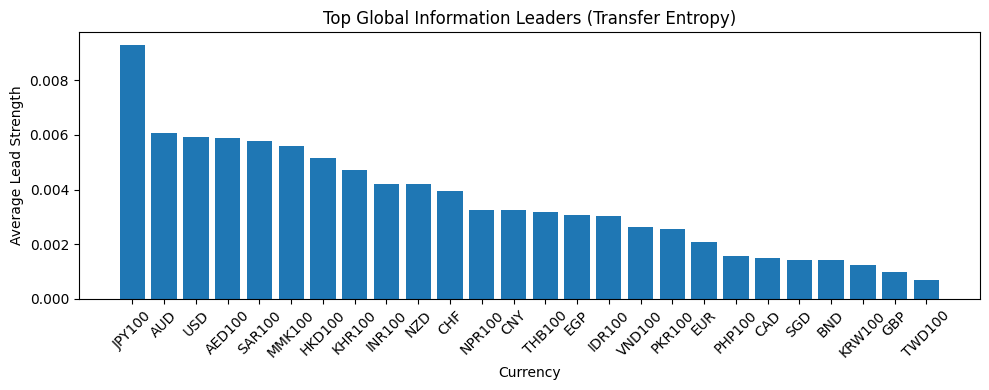

In [5]:
# =========================================================
# Top Leaders (most influential currencies)
# =========================================================

import matplotlib.pyplot as plt

top_n = 26
leaders_plot = df_global_leaders.head(top_n)

plt.figure(figsize=(10, 4))
plt.bar(leaders_plot['Currency'], leaders_plot['Average_Lead_Strength'])
plt.xticks(rotation=45)
plt.title("Top Global Information Leaders (Transfer Entropy)")
plt.xlabel("Currency")
plt.ylabel("Average Lead Strength")
plt.tight_layout()
plt.show()

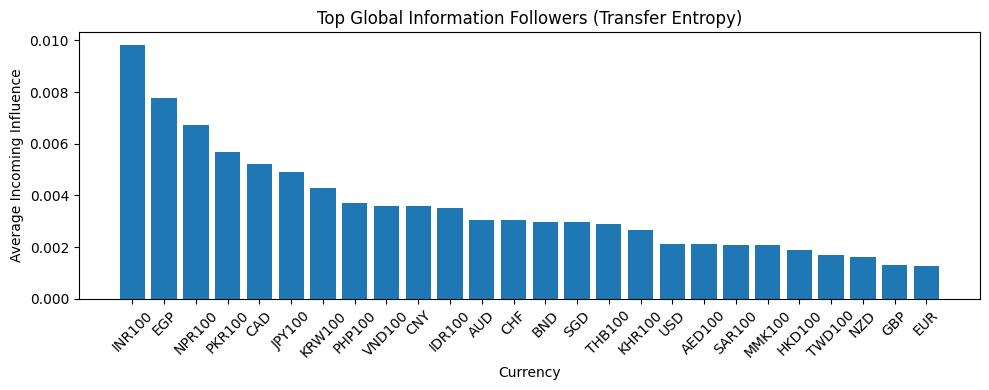

In [6]:
# =========================================================
# Top Followers (most influenced currencies)
# =========================================================

top_n = 26

followers = (
    df_mesh
    .groupby('Target')['Lead_Strength']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

followers_plot = followers.head(top_n)

plt.figure(figsize=(10, 4))
plt.bar(followers_plot['Target'], followers_plot['Lead_Strength'])
plt.xticks(rotation=45)
plt.title("Top Global Information Followers (Transfer Entropy)")
plt.xlabel("Currency")
plt.ylabel("Average Incoming Influence")
plt.tight_layout()
plt.show()

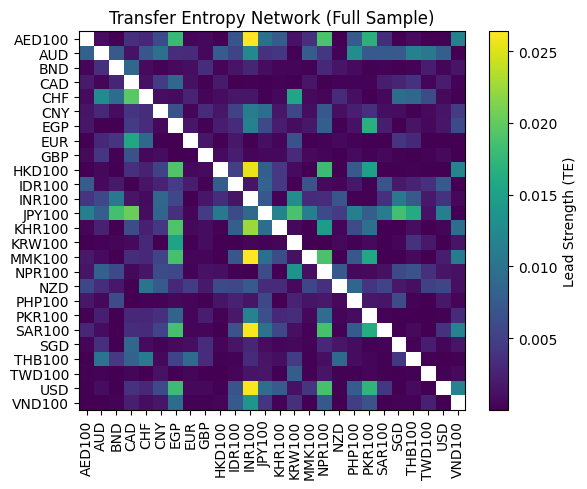

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Pivot into matrix form
te_matrix = df_mesh.pivot(index='Source', columns='Target', values='Lead_Strength')

plt.figure(figsize=(6,5))
plt.imshow(te_matrix, aspect='auto')
plt.colorbar(label="Lead Strength (TE)")
plt.xticks(range(len(te_matrix.columns)), te_matrix.columns, rotation=90)
plt.yticks(range(len(te_matrix.index)), te_matrix.index)
plt.title("Transfer Entropy Network (Full Sample)")
plt.tight_layout()
plt.show()

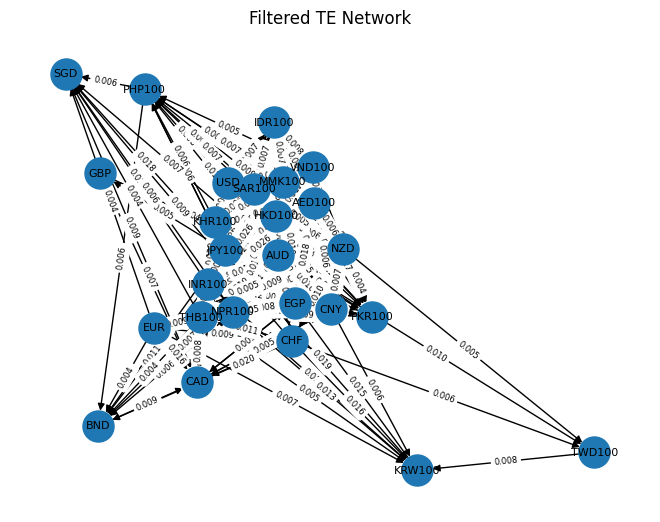

In [8]:
import networkx as nx

threshold = 0.004  # tune this
df_sig = df_mesh[df_mesh['Lead_Strength'] > threshold]

G = nx.from_pandas_edgelist(
    df_sig,
    source='Source',
    target='Target',
    edge_attr='Lead_Strength',
    create_using=nx.DiGraph()
)

plt.figure()
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=500, font_size=8)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u,v): f"{d['Lead_Strength']:.3f}" for u,v,d in G.edges(data=True)},
    font_size=6
)

plt.title("Filtered TE Network")
plt.show()

The bar chart of global information leaders provides a clear summary of the system. It ranks currencies by their average outgoing transfer entropy, capturing their overall influence on the rest of the network. Currencies such as JPY100, AUD, and USD emerge as dominant sources of information flow, indicating that their past movements contain predictive content for a wide range of other currencies.

The heatmap offers a complementary perspective by displaying the full pairwise structure of the network. Each row represents a source currency and each column a target currency, with color intensity reflecting the strength of directed influence. This visualization highlights asymmetries and clustering patterns that are not immediately visible in the aggregate rankings, such as concentrations of influence toward specific currencies.

The network graph provides an intuitive representation of directed relationships after filtering out weak links using a threshold of 0.004. This threshold is chosen based on the average level of influence in the system, allowing us to focus on economically meaningful connections while suppressing noise. The resulting graph highlights the strongest pathways of information flow across currencies.

However, even after thresholding, the network remains visually dense and difficult to interpret. The presence of cycles and overlapping connections obscures the underlying structure of influence. This motivates a more structured approach: partitioning the network into strongly connected components and collapsing them into super-nodes. By doing so, we transform the network into a directed acyclic graph, revealing a clearer hierarchical organization of influence across groups of currencies rather than individual nodes.

Original Nodes: 24
Original Edges (after threshold): 61
Super-nodes (SCCs): 19

--- STRONGLY CONNECTED COMPONENTS (Top 10 by size) ---
Component 1 (size 4): ['EGP', 'INR100', 'KRW100', 'PKR100']
Component 2 (size 3): ['AUD', 'CHF', 'THB100']
Component 3 (size 1): ['SGD']
Component 4 (size 1): ['BND']
Component 5 (size 1): ['VND100']
Component 6 (size 1): ['NPR100']
Component 7 (size 1): ['USD']
Component 8 (size 1): ['CAD']
Component 9 (size 1): ['EUR']
Component 10 (size 1): ['HKD100']

--- GLOBAL COMMANDERS (No incoming influence) ---
[{'EUR'}, {'JPY100'}, {'CNY'}, {'NZD'}]

--- TERMINAL SINKS (No outgoing influence) ---
[{'SGD'}, {'BND'}, {'CAD'}, {'PHP100'}, {'TWD100'}]


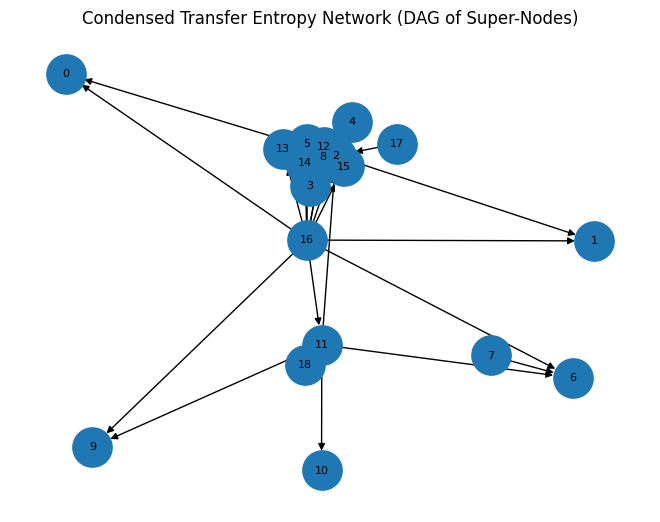

In [9]:
# =========================================================
# Condensation: From raw network to hierarchical structure
# =========================================================

import networkx as nx
import matplotlib.pyplot as plt

# 1. Build directed graph using your chosen threshold
threshold = 0.01
df_sig = df_mesh[df_mesh['Lead_Strength'] > threshold].copy()

G = nx.from_pandas_edgelist(
    df_sig,
    source='Source',
    target='Target',
    edge_attr='Lead_Strength',
    create_using=nx.DiGraph()
)

print(f"Original Nodes: {len(G.nodes())}")
print(f"Original Edges (after threshold): {len(G.edges())}")

# 2. Condensation (collapse strongly connected components)
C = nx.condensation(G)

print(f"Super-nodes (SCCs): {len(C.nodes())}")

# 3. Extract components
components = list(nx.strongly_connected_components(G))

# Sort by size (largest first)
components_sorted = sorted(components, key=lambda x: len(x), reverse=True)

print("\n--- STRONGLY CONNECTED COMPONENTS (Top 10 by size) ---")
for i, comp in enumerate(components_sorted[:10]):
    print(f"Component {i+1} (size {len(comp)}): {sorted(list(comp))}")

# 4. Identify hierarchy
top_level = [data['members'] for n, data in C.nodes(data=True) if C.in_degree(n) == 0]
bottom_level = [data['members'] for n, data in C.nodes(data=True) if C.out_degree(n) == 0]

print("\n--- GLOBAL COMMANDERS (No incoming influence) ---")
print(top_level)

print("\n--- TERMINAL SINKS (No outgoing influence) ---")
print(bottom_level)

# 5. Visualize condensed graph (clean DAG)
plt.figure()
pos = nx.spring_layout(C, seed=42)

nx.draw(C, pos, with_labels=True, node_size=800, font_size=8)
plt.title("Condensed Transfer Entropy Network (DAG of Super-Nodes)")
plt.show()

### From Dense Network to Hierarchical Structure

The thresholded network remains difficult to interpret due to the presence of cycles and overlapping influence paths. To address this, we partition the network into strongly connected components, where each component represents a group of currencies that mutually influence one another through directed paths.

Each such component can be viewed as an equivalence class under mutual reachability. By collapsing these components into super-nodes, we obtain a condensed network that is guaranteed to be acyclic. This transformation removes return paths and reveals a clearer hierarchical structure of influence.

In this condensed representation, nodes with no incoming edges represent top-level drivers of the system, while nodes with no outgoing edges represent terminal sinks that primarily absorb influence. This provides a more interpretable, system-level view of how influence propagates across the currency network.

In the context of foreign exchange markets, this hierarchical structure can be interpreted in economic terms. Super-nodes with no incoming edges represent currencies, or groups of currencies, whose movements are largely driven by factors external to the network under consideration. These can be viewed as **global drivers**, such as major reserve or anchor currencies, whose price dynamics reflect broader macroeconomic forces (e.g., global liquidity, interest rate differentials, or risk sentiment) rather than being influenced by other currencies in the system.

Conversely, super-nodes with no outgoing edges represent **terminal currencies** that primarily absorb information from the rest of the network. These currencies tend to adjust in response to movements in more influential currencies and may reflect local or regional conditions that are sensitive to external shocks. In practical terms, they behave more like **price takers** in the global FX ecosystem.

Between these extremes, intermediate super-nodes capture clusters of currencies that mutually influence one another, often reflecting regional linkages, trade relationships, or shared economic structures. The condensation thus reveals not only individual influence, but also **blocks of interdependent currencies** and the direction in which information propagates across the global FX system.

### Effect of Threshold Selection on Network Structure

The choice of threshold has a significant impact on the structure of the resulting network. At a lower threshold (e.g., 0.004), a large number of edges are retained, resulting in a densely connected graph. In such a setting, most currencies become mutually reachable through directed paths, causing the entire network to collapse into a single strongly connected component. This leads to a single super-node in the condensation step, effectively obscuring any hierarchical structure.

As the threshold is increased (e.g., 0.01), weaker links are pruned away, and only stronger, more economically meaningful connections remain. This reduces the overall connectivity of the graph, breaking many of the return paths that previously linked currencies together. As a result, the network decomposes into multiple strongly connected components, revealing a more interpretable structure.

In the present case, the emergence of multi-currency components such as

$\text{Component 1} = \{\text{EGP, INR100, KRW100, PKR100}\}$ and

$\text{Component 2} = \{\text{AUD, CHF, THB100}\}$

suggests clusters of currencies with mutual influence, potentially reflecting regional or economic linkages. At the same time, the appearance of singleton nodes indicates currencies that are no longer part of any feedback loop at this level of significance.

The identification of “global commanders” (e.g., EUR, JPY100, CNY, NZD) indicates currencies that act as upstream drivers, influencing others without being influenced within this filtered network. Conversely, “terminal sinks” (e.g., SGD, BND, CAD) represent currencies that primarily absorb influence but do not propagate it further.

Overall, increasing the threshold serves as a filtering mechanism that removes noise and reveals the **core directional structure** of the system. However, the choice of threshold is inherently a trade-off: too low leads to an overly dense and uninformative network, while too high risks discarding meaningful relationships.

---

### **Demonstration 2**: Granger Causality Network Construction (Full Sample)

We now construct a directed influence network using Granger causality on the full sample of data. The objective of this step is to quantify pairwise, lagged predictive relationships between currencies and assemble these relationships into a network representation.

For each ordered pair of currencies $(X, Y)$, we test whether past values of $X$ provide statistically significant information about $Y_t$ beyond what is contained in the past of $Y$ itself. This is implemented using a fixed lag structure (`lag=1`) within a linear autoregressive framework. The resulting measure captures directional, lagged influence in a parametric setting.

By repeating this procedure across all currency pairs, we obtain a full mesh of directed relationships. These relationships are typically summarized using test statistics or p-values, which can be interpreted as the strength or significance of predictive influence from the source currency to the target currency.

The resulting output will again be presented in two forms. First, we identify the strongest individual directed links in the system based on statistical significance. Second, we aggregate the results to produce a ranking of currencies according to their overall influence, providing a system-wide view of predictive leadership.

This analysis provides a linear, model-based counterpart to the transfer entropy approach presented earlier. Comparing the two allows us to assess the robustness of inferred relationships and to identify potential nonlinear effects that may not be captured by Granger causality.

In [10]:
import warnings
import contextlib
import io
from statsmodels.tsa.stattools import grangercausalitytests

# Suppress warnings globally
warnings.filterwarnings("ignore")

# =========================================================
# 2. Full-mesh Granger Causality analysis
# =========================================================

all_currencies = available_cols
gc_results = []
gc_failed_pairs = []
lag_order = 1

print(f"\nAnalyzing full Granger causality mesh with {len(all_currencies)} currencies and lag={lag_order}...")

for source in all_currencies:
    print(f"Processing source: {source}...", end="\r")
    for target in all_currencies:
        if source == target:
            continue

        try:
            # Prepare data
            test_data = df_returns[[target, source]].dropna()
            reverse_data = df_returns[[source, target]].dropna()

            # Suppress internal prints
            with contextlib.redirect_stdout(io.StringIO()):
                result = grangercausalitytests(test_data, maxlag=lag_order)
                reverse_result = grangercausalitytests(reverse_data, maxlag=lag_order)

            # Extract p-values
            p_value = result[lag_order][0]['ssr_ftest'][1]
            reverse_p_value = reverse_result[lag_order][0]['ssr_ftest'][1]

            # Convert to "strength"
            lead_strength = -np.log(p_value + 1e-12)
            feedback_strength = -np.log(reverse_p_value + 1e-12)

            gc_results.append({
                'Source': source,
                'Target': target,
                'Lead_Strength': float(lead_strength),
                'Feedback_Strength': float(feedback_strength),
                'Net_Influence': float(lead_strength - feedback_strength)
            })

        except Exception as e:
            gc_failed_pairs.append((source, target, str(e)))

print("\nFull-mesh Granger causality analysis completed.")
print(f"Successful directed pairs: {len(gc_results)}")
print(f"Failed directed pairs: {len(gc_failed_pairs)}")

# =========================================================
# 3. Create result DataFrame
# =========================================================

df_gc_mesh = pd.DataFrame(gc_results)

if df_gc_mesh.empty:
    print("\ndf_gc_mesh is empty.")
else:
    # =====================================================
    # 4. Top links
    # =====================================================

    gc_top_links = (
        df_gc_mesh
        .sort_values(by='Lead_Strength', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    print("\n--- TOP 20 DIRECTED LINKS BY LEAD STRENGTH ---")
    print(gc_top_links[['Source', 'Target', 'Lead_Strength', 'Feedback_Strength', 'Net_Influence']].to_string(index=False))

    # =====================================================
    # 5. Global leaders
    # =====================================================

    gc_global_leaders = (
        df_gc_mesh
        .groupby('Source')['Lead_Strength']
        .mean()
        .sort_values(ascending=False)
    )

    print("\n--- GLOBAL INFORMATION LEADERSHIP RANKING (AVERAGE OUTGOING GC) ---")
    print(gc_global_leaders.to_string())

    df_gc_global_leaders = gc_global_leaders.reset_index()
    df_gc_global_leaders.columns = ['Currency', 'Average_Lead_Strength']


Analyzing full Granger causality mesh with 26 currencies and lag=1...

Full-mesh Granger causality analysis completed.
Successful directed pairs: 650
Failed directed pairs: 0

--- TOP 20 DIRECTED LINKS BY LEAD STRENGTH ---
Source Target  Lead_Strength  Feedback_Strength  Net_Influence
AED100 INR100       9.562390           2.081175       7.481215
MMK100 INR100       9.534812           1.802316       7.732496
   USD INR100       9.487330           2.045874       7.441456
SAR100 INR100       9.477239           1.963375       7.513864
HKD100 INR100       9.296934           1.902170       7.394764
KHR100 INR100       8.309949           0.350344       7.959605
JPY100    CAD       7.684668           0.204244       7.480424
   CHF    CAD       7.402186           0.930138       6.472048
HKD100    EGP       7.283544           1.341499       5.942045
KHR100    EGP       7.244480           1.338737       5.905743
AED100 NPR100       7.161710           1.053601       6.108109
JPY100 KRW100       

### Interpretation

The Granger causality analysis provides a model-based, linear perspective on directed influence within the currency network. As in the transfer entropy case,

1. `Lead_Strength` measures the influence from a source currency to a target currency,
2. `Feedback_Strength` captures the reverse direction, and
3. `Net_Influence` reflects the directional dominance.

Here, however, `Lead_Strength` is derived from the statistical significance of the Granger causality test, with higher values corresponding to stronger predictive relationships (i.e., lower p-values).

The strongest directed links exhibit a pattern highly consistent with the transfer entropy results. In particular, INR100 again appears as a major recipient of influence, with multiple currencies—USD, AED100, SAR100, HKD100, and others—showing strong predictive power over its movements. This reinforces the interpretation that INR behaves as a responsive currency within the system, absorbing information from both global and regional drivers.

At the aggregate level, the ranking of currencies by average outgoing influence is also broadly aligned with the transfer entropy findings. JPY100, AUD, and USD emerge as the most influential currencies, indicating that their lagged values contain significant predictive information for a wide range of other currencies. This consistency across both methods suggests that these currencies play a structurally central role in the global FX network.

The close correspondence between the Granger causality and transfer entropy results is notable. Despite relying on different theoretical foundations—linear regression versus information theory—both approaches identify similar directional relationships and influence hierarchies. This provides a degree of robustness to the findings, while also suggesting that the dominant dependencies in this dataset are largely linear in nature.

As with the transfer entropy analysis, it is important to note that these results are based on the full sample and therefore represent an average over time. The rolling analysis that follows will allow us to examine how these relationships evolve across different market conditions.

The following code quantifies the similarity between the transfer entropy and Granger causality networks by comparing pairwise influence strengths, overall leadership rankings, and the overlap among the strongest directed links.

In [11]:
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import numpy as np

# =========================================================
# Compare TE and Granger results
# =========================================================

# 1. Pairwise edge-level comparison
df_compare_edges = pd.merge(
    df_mesh[['Source', 'Target', 'Lead_Strength']].rename(columns={'Lead_Strength': 'TE_Lead'}),
    df_gc_mesh[['Source', 'Target', 'Lead_Strength']].rename(columns={'Lead_Strength': 'GC_Lead'}),
    on=['Source', 'Target'],
    how='inner'
)

pearson_edge = pearsonr(df_compare_edges['TE_Lead'], df_compare_edges['GC_Lead'])[0]
spearman_edge = spearmanr(df_compare_edges['TE_Lead'], df_compare_edges['GC_Lead'])[0]

# 2. Source-level leadership comparison
df_compare_leaders = pd.merge(
    df_global_leaders.rename(columns={'Average_Lead_Strength': 'TE_Avg_Lead'}),
    df_gc_global_leaders.rename(columns={'Average_Lead_Strength': 'GC_Avg_Lead'}),
    on='Currency',
    how='inner'
)

pearson_leader = pearsonr(df_compare_leaders['TE_Avg_Lead'], df_compare_leaders['GC_Avg_Lead'])[0]
spearman_leader = spearmanr(df_compare_leaders['TE_Avg_Lead'], df_compare_leaders['GC_Avg_Lead'])[0]

# 3. Top-k overlap
k = 20

te_top_k = set(
    df_mesh.sort_values('Lead_Strength', ascending=False)
    .head(k)
    .apply(lambda row: (row['Source'], row['Target']), axis=1)
)

gc_top_k = set(
    df_gc_mesh.sort_values('Lead_Strength', ascending=False)
    .head(k)
    .apply(lambda row: (row['Source'], row['Target']), axis=1)
)

top_k_overlap = len(te_top_k & gc_top_k)
top_k_overlap_ratio = top_k_overlap / k

# 4. Print summary
print("--- TE vs Granger Similarity Metrics ---")
print(f"Number of common directed edges compared: {len(df_compare_edges)}")
print(f"Edge-level Pearson correlation:  {pearson_edge:.4f}")
print(f"Edge-level Spearman correlation: {spearman_edge:.4f}")
print()
print(f"Number of common currencies compared: {len(df_compare_leaders)}")
print(f"Leader-level Pearson correlation:  {pearson_leader:.4f}")
print(f"Leader-level Spearman correlation: {spearman_leader:.4f}")
print()
print(f"Top-{k} overlap count: {top_k_overlap}")
print(f"Top-{k} overlap ratio: {top_k_overlap_ratio:.2%}")

--- TE vs Granger Similarity Metrics ---
Number of common directed edges compared: 650
Edge-level Pearson correlation:  0.9944
Edge-level Spearman correlation: 1.0000

Number of common currencies compared: 26
Leader-level Pearson correlation:  0.9957
Leader-level Spearman correlation: 0.9952

Top-20 overlap count: 20
Top-20 overlap ratio: 100.00%


### Comparison Between Transfer Entropy and Granger Causality

The similarity metrics indicate an exceptionally high degree of agreement between the transfer entropy and Granger causality networks. At the edge level, both the Pearson and Spearman correlations are effectively equal to one, implying that the pairwise influence strengths are almost perfectly aligned across the two methods. This suggests that, for nearly all ordered currency pairs, the relative magnitude and ranking of directional influence are consistent.

At the aggregate level, the leadership rankings also exhibit near-perfect correspondence. The high correlation between average outgoing influence across currencies indicates that both methods identify the same set of currencies as dominant sources of information flow within the system. This reinforces the robustness of the earlier findings regarding global influence hierarchy.

Furthermore, the complete overlap in the top-20 directed links confirms that the strongest relationships identified by transfer entropy are identical to those identified by Granger causality. This level of agreement is particularly striking given the different theoretical foundations of the two approaches.

Taken together, these results suggest that the underlying dependency structure in the dataset is largely **linear**, in the sense that the dominant directional relationships can be well captured by linear autoregressive models. In other words, the “structure” of the network—referring to the pattern of directed influence across currencies—is such that nonlinear effects, if present, do not materially alter the identification of key relationships in the full-sample analysis.

This high degree of consistency provides confidence in the inferred network, suggesting that the dominant relationships are stable and well-captured under both linear and information-theoretic frameworks. However, it remains a full-sample, time-averaged result, which may mask important temporal variations in influence. In Part 2, we extend the analysis to a rolling framework to examine whether this agreement persists across different market regimes, and to identify periods where the structure of influence may deviate, strengthen, or reorganize over time.